In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings
import os

# Importamos SOLO NHITS
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MSE, MAE

warnings.filterwarnings('ignore')
print("✅ Librerías para NHITS cargadas.")

d:\programas\tfm\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 13:21:17,419	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-09 13:21:17,637	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


✅ Librerías para NHITS cargadas.


In [2]:
filename = "dataset_tfm_56_survivors.csv"

if os.path.exists(filename):
    df = pd.read_csv(filename)
    df['ds'] = pd.to_datetime(df['ds'])
    
    # 1. Filtro de Seguridad
    counts = df.groupby('unique_id').size().reset_index(name='n_days')
    # 335 días = 60 input + 5 horizonte + ~260 validación + margen
    MIN_REQUIRED = 335 
    valid_ids = counts[counts['n_days'] > MIN_REQUIRED]['unique_id'].unique()
    
    df = df[df['unique_id'].isin(valid_ids)].copy()
    print(f"✅ Empresas aptas tras filtro: {df['unique_id'].nunique()}")

    # 2. Preprocesamiento
    df = df[(df['y'] <= 0.5) & (df['y'] >= -0.5)].copy()
    stats = df.groupby('unique_id')['y'].agg(['mean', 'std']).reset_index()
    df = pd.merge(df, stats, on='unique_id', how='left')
    df['y_norm'] = (df['y'] - df['mean']) / (df['std'] + 1e-8)

    df_final = df.copy()
    df_final['y_raw'] = df_final['y']
    df_final['y'] = df_final['y_norm']
    df_final = df_final[['unique_id', 'ds', 'y', 'y_raw']].dropna()
    df_final = df_final.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

    df_input = df_final.copy()
    
    # Val Size Caso 3 (2023)
    VAL_YEAR = 2023
    df_2023 = df_input[df_input['ds'].dt.year == VAL_YEAR]
    if len(df_2023) > 0:
        val_size = int(df_2023.groupby('unique_id').size().median())
        print(f"✅ Datos listos. Validación: {val_size} días.")
    else:
        print("❌ ERROR: No hay datos en 2023.")

else:
    print(f"❌ ERROR: No se encuentra el archivo '{filename}'.")

✅ Empresas aptas tras filtro: 56
✅ Datos listos. Validación: 255 días.


In [3]:
def ejecutar_nhits_final(param_grid, df_train, val_size):
    print(f"\n🚀 INICIANDO GRID SEARCH PARA NHITS (Caso 3)")
    print(f"   📂 Archivo de salida: grid_search_NHITS_case3.csv")
    
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    HORIZONTE = 5
    INPUT_SIZE_FIJO = 60

    for i, params in enumerate(combinations):
        print(f"   ⚙️ [{i+1}/{len(combinations)}] Probando: {params} ...", end=" ")
        
        try:
            # --- CORRECCIÓN DE PARÁMETROS ---
            # NHITS necesita listas de listas para sus capas
            
            # 1. Definimos los bloques por stack. NHITS tiene 3 stacks por defecto.
            #    Si n_blocks_depth=1 -> [1, 1, 1]
            current_n_blocks = [params['n_blocks_depth']] * 3
            
            # 2. Definimos las mlp_units (neuronas) para cada stack.
            #    Si hidden_size=512 -> [[512, 512], [512, 512], [512, 512]]
            #    (Usamos 2 capas densas por bloque, que es el estándar)
            current_mlp_units = [[params['hidden_size'], params['hidden_size']]] * 3

            model = NHITS(
                h=HORIZONTE,
                input_size=INPUT_SIZE_FIJO,
                loss=MSE(),
                valid_loss=MAE(),
                max_steps=300,
                scaler_type='identity',
                start_padding_enabled=True,
                
                # PARÁMETROS FIJOS
                n_freq_downsample=[2, 1, 1], # Downsample estándar para diario
                
                # PARÁMETROS VARIABLES TRADUCIDOS
                mlp_units=current_mlp_units,
                n_blocks=current_n_blocks,
                
                random_seed=42
            )
            
            nf = NeuralForecast(models=[model], freq='B')
            nf.fit(df=df_train, val_size=val_size)
            
            cutoff_date = f"{VAL_YEAR}-01-01"
            df_history = df_train[df_train['ds'] < cutoff_date].copy()
            forecasts = nf.predict(df=df_history).reset_index()
            
            combined = pd.merge(forecasts, df_train[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')
            col_pred = 'NHITS'
            mae = (combined['y'] - combined[col_pred]).abs().mean()
            
            # Robustez
            errors_per_id = combined.groupby('unique_id').apply(
                lambda x: (x['y'] - x[col_pred]).abs().mean()
            ).reset_index(name='MAE_Empresa')
            
            vol_data = []
            for uid in df_history['unique_id'].unique():
                series = df_history[df_history['unique_id']==uid]['y']
                v = series.tail(INPUT_SIZE_FIJO).std() if len(series) >= INPUT_SIZE_FIJO else 0
                vol_data.append({'unique_id': uid, 'Input_Vol': v})
            
            df_vol = pd.DataFrame(vol_data)
            analysis = pd.merge(df_vol, errors_per_id, on='unique_id')
            corr = analysis['Input_Vol'].corr(analysis['MAE_Empresa'])
            
            print(f"✅ MAE: {mae:.5f} | Corr: {corr:.4f}")
            
            res = params.copy()
            res['MAE'] = mae
            res['Correlacion'] = corr
            results.append(res)
            
        except Exception as e:
            print(f"❌ Error: {e}")

    if results:
        df_res = pd.DataFrame(results).sort_values('MAE')
        df_res.to_csv("grid_search_NHITS_case3.csv", index=False)
        print(f"\n🏆 GANADOR NHITS: MAE {df_res.iloc[0]['MAE']:.5f}")

In [6]:
grid_nhits_params = {
    'hidden_size': [256, 512, 1024, 2048], 
    'n_blocks_depth': [1, 2, 3] 
}
print("📋 Parámetros NHITS listos.")

📋 Parámetros NHITS listos.


In [7]:
ejecutar_nhits_final(grid_nhits_params, df_input, val_size)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | valid_loss   | MAE           | 0      | train | 0    
2 | padder_train | ConstantPad1d | 0      | train | 0    
3 | scaler       | TemporalNorm  | 0      | train | 0    
4 | blocks       | ModuleList    | 672 K  | train | 0    
---------------------------------------------------------------
672 K     Trainable params
0         Non-trainable params
672 K     Total params
2.692     Total estimated model params size (MB)
35        Modules in train mode
0         Modules in eval mode
0         Total Flops



🚀 INICIANDO GRID SEARCH PARA NHITS (Caso 3)
   📂 Archivo de salida: grid_search_NHITS_case3.csv
Epoch 149: 100%|██████████| 2/2 [00:00<00:00, 26.73it/s, v_num=53, train_loss_step=0.926, train_loss_epoch=0.944, valid_loss=0.553]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 149: 100%|██████████| 2/2 [00:00<00:00, 26.02it/s, v_num=53, train_loss_step=0.926, train_loss_epoch=0.944, valid_loss=0.553]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 149: 100%|██████████| 2/2 [00:01<00:00,  1.12it/s, v_num=75, train_loss_step=0.934, train_loss_epoch=0.949, valid_loss=0.551]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 149: 100%|██████████| 2/2 [00:01<00:00,  1.12it/s, v_num=75, train_loss_step=0.934, train_loss_epoch=0.949, valid_loss=0.551]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 109.79it/s]
✅ MAE: 0.67286 | Corr: 0.3801

🏆 GANADOR NHITS: MAE 0.66070


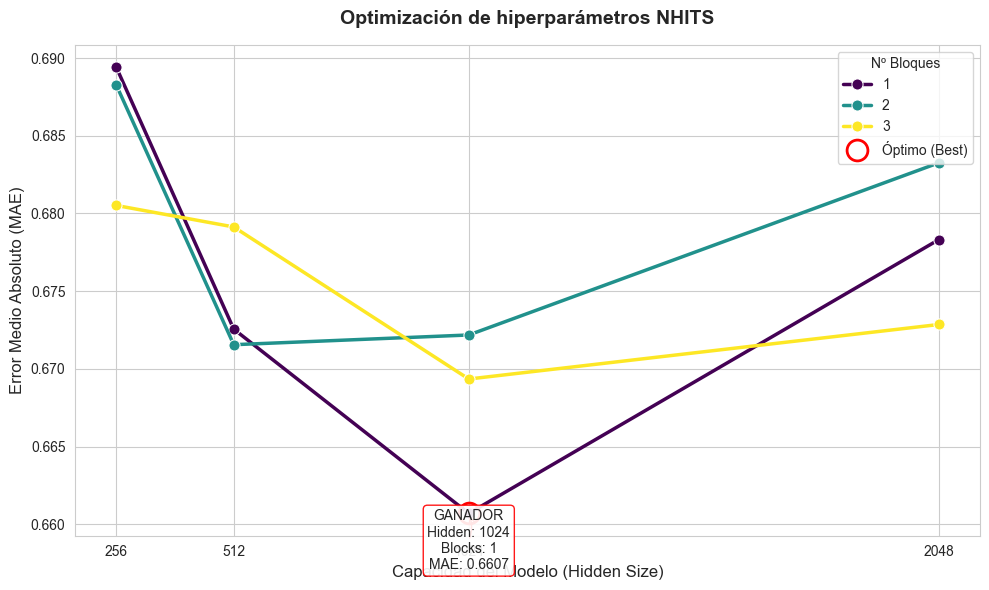

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGA MANUAL DE TUS RESULTADOS (NHITS)
data = {
    'hidden_size': [1024, 1024, 512, 1024, 512, 2048, 2048, 512, 256, 2048, 256, 256],
    'n_blocks_depth': [1, 3, 2, 2, 1, 3, 1, 3, 3, 2, 2, 1],
    'MAE': [
        0.6607021748217786, 0.6693487685696095, 0.6715570076492133, 
        0.6721823109351591, 0.6725581409403358, 0.6728571525054448, 
        0.6783198570103697, 0.6791315138883468, 0.6805167690564888, 
        0.6832596813261727, 0.6882724191314031, 0.6894144565353382
    ]
}

df_results = pd.DataFrame(data)

# 2. CONFIGURACIÓN DEL GRÁFICO ACADÉMICO
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Lineplot: Eje X (Hidden Size) vs Eje Y (Error)
# Agrupado por Profundidad (hue='n_blocks_depth')
ax = sns.lineplot(
    data=df_results, 
    x='hidden_size', 
    y='MAE', 
    hue='n_blocks_depth', 
    palette='viridis',  # Usamos 'magma' para diferenciarlo del LSTM
    marker='o', 
    linewidth=2.5,
    markersize=8
)

# 3. DESTACAR EL GANADOR (1024, 1)
best_row = df_results.loc[df_results['MAE'].idxmin()]

# Círculo rojo
plt.plot(best_row['hidden_size'], best_row['MAE'], 'o', 
         ms=15, mfc='none', mec='red', mew=2, label='Óptimo (Best)')

# Anotación
plt.annotate(
    f"GANADOR\nHidden: {int(best_row['hidden_size'])}\nBlocks: {int(best_row['n_blocks_depth'])}\nMAE: {best_row['MAE']:.4f}",
    xy=(best_row['hidden_size'], best_row['MAE']),
    xytext=(0, -40), textcoords='offset points',
    ha='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color='red', connectionstyle="arc3,rad=.2")
)

# 4. FORMATO FINAL
plt.title('Optimización de hiperparámetros NHITS', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Error Medio Absoluto (MAE)', fontsize=12)
plt.xlabel('Capacidad del Modelo (Hidden Size)', fontsize=12)
plt.xticks([256, 512, 1024, 2048]) # Forzamos la escala logarítmica visual
plt.legend(title='Nº Bloques', loc='upper right')

plt.tight_layout()
plt.savefig('grid_search_nhits_results.png', dpi=300)
plt.show()